In [1]:
import sys
sys.path.append(r'/import/home2/yzengbj/my_project/code')
import SVF

import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import scipy.io
import matplotlib.pyplot as plt
import libpysal
import numpy as np
import esda
from libpysal.weights import KNN

import warnings
warnings.filterwarnings("ignore")
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:
import matplotlib as mpl
from matplotlib import cm
mpl.rcParams.update({
    "pdf.fonttype": 42,          # 42 保留文字为可编辑的 TrueType（AI 友好）
    "ps.fonttype": 42,
    #"font.sans-serif": ["Helvetica"],  # 或者 "Helvetica"
    "axes.linewidth": 0.8,
})

#cmap = cm.vik.copy()
#cmap.set_bad(color="#E6E6E6")

mpl.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

In [3]:
DATA_PATH = "/import/home2/share/yqzeng/MacSGP/results/simulation/shifted" # Processed data
SAVE_PATH = "/import/home2/share/yqzeng/MacSGP/results/simulation/shifted" # Deconvolution results
FIG_PATH = "/import/home2/share/yqzeng/MacSGP/experiments/simulation/figs" # Figures

In [4]:
c_list = [0.005, 0.01, 0.1, 1, 100]

In [5]:
factors = []
loadings = []
spatial_coherence = pd.DataFrame(index=c_list, columns=['nmf','mofa', 'spicemix', 'stamp', 'macsgp'])
program_coherence = pd.DataFrame(index=c_list, columns=['nmf','mofa', 'spicemix', 'stamp', 'macsgp'])


In [6]:
program_coherence

,nmf,mofa,spicemix,stamp,macsgp
0.005,NaN,NaN,NaN,NaN,NaN
0.010,NaN,NaN,NaN,NaN,NaN
0.100,NaN,NaN,NaN,NaN,NaN
1.000,NaN,NaN,NaN,NaN,NaN
100.000,NaN,NaN,NaN,NaN,NaN


## c = 100

In [7]:
c=100
adata_result = sc.read_h5ad(os.path.join(SAVE_PATH, f'adata_result_macsgp_c{c}.h5ad'))
coords = adata_result.obsm['spatial']
factor_true = adata_result.obsm['simulated_factor']['celltype_0']
loading_true = adata_result.varm['simulated_loading'][:, 0]

In [8]:
for method in ['mofa', 'spicemix', 'stamp']:
    factor_i = pd.read_csv(os.path.join(SAVE_PATH, method, f'factors_{c}.csv'), index_col=0)
    adata_st = adata_result.copy()
    for i in range(factor_i.shape[1]):
        adata_st.obs[f'{method}_factor_{i}'] = factor_i.iloc[:, i].values
    # sc.pl.spatial(adata_st, color=[f'{method}_factor_{i}' for i in range(factor_i.shape[1])], 
    #               cmap='viridis', spot_size=0.05, ncols=5)
    # draw in one row 

In [9]:
methods = ['mofa', 'spicemix', 'stamp']
factors_temp = []
loadings_temp = []
for method in methods:
    factor_i = pd.read_csv(os.path.join(SAVE_PATH, method, f'factors_{c}.csv'), index_col=0)
    factors_temp.append(factor_i)
    loading_i = pd.read_csv(os.path.join(SAVE_PATH, method, f'loadings_{c}.csv'), index_col=0)
    loading_i = loading_i.loc[adata_result.var_names, :]
    loadings_temp.append(loading_i)

factor_ct_df = (np.concatenate([factors_temp[0].iloc[:, 0].values.reshape(-1, 1), factors_temp[1].iloc[:, 3].values.reshape(-1, 1), 
                factors_temp[2].iloc[:, 2].values.reshape(-1, 1)], axis=1))

loading_ct_df = (np.concatenate([loadings_temp[0].iloc[:, 0].values.reshape(1, -1), loadings_temp[1].iloc[:, 3].values.reshape(1, -1), 
                loadings_temp[2].iloc[:, 2].values.reshape(1, -1)], axis=0))

factor_ct_df = pd.DataFrame(factor_ct_df, index=adata_st.obs_names, columns=methods)
loading_ct_df = pd.DataFrame(loading_ct_df, index=methods, columns=adata_st.var_names)

factor_ct_df['macsgp'] = adata_st[factor_ct_df.index, :].obsm['factor']['celltype_0']
factor_ct_df['true'] = pd.DataFrame(adata_st[factor_ct_df.index, :].obsm['simulated_factor']['celltype_0'].values, columns=['true'], index=factor_ct_df.index)
loading_ct_df.loc['macsgp', :] = adata_st[factor_ct_df.index, :].varm['loading']['celltype_0']

nmf_idx = 0  # TODO: change after visualization
nmf_factor_i  = pd.read_csv(os.path.join(SAVE_PATH, 'NMF', f'factors_{c}.csv'),  index_col=0)
nmf_loading_i = pd.read_csv(os.path.join(SAVE_PATH, 'NMF', f'loadings_{c}.csv'), index_col=0)
factor_ct_df['nmf'] = nmf_factor_i.iloc[:, nmf_idx].values
loading_ct_df.loc['nmf', :] = nmf_loading_i.iloc[:, nmf_idx].values

# normalized factor_ct_df to -1 to 1
factor_ct_df_norm = factor_ct_df.copy()
for col in factor_ct_df_norm.columns:
    min_val = factor_ct_df_norm[col].min()
    max_val = factor_ct_df_norm[col].max()
    factor_ct_df_norm[col] = 2 * (factor_ct_df_norm[col] - min_val) / (max_val - min_val) - 1

In [10]:
proportion = adata_st.obsm['proportion']['celltype_0']
threshold = 0.0
w = KNN.from_array(coords[proportion > threshold], k=9)
w.transform = 'r'  # 行标准化
spatial_coherence_c = []
# filter spots with low proportions
bi = esda.Moran_BV(factor_ct_df['true'][proportion > threshold], factor_ct_df['nmf'][proportion > threshold], w, permutations=999)
spatial_coherence_c.append(abs(bi.I))
for method in methods:
    bi = esda.Moran_BV(factor_ct_df['true'][proportion > threshold], factor_ct_df[method][proportion > threshold], w, permutations=999)
    spatial_coherence_c.append(abs(bi.I))
bi = esda.Moran_BV(factor_ct_df['true'][proportion > threshold], factor_ct_df['macsgp'][proportion > threshold], w, permutations=999)
spatial_coherence_c.append(abs(bi.I))

In [11]:
spatial_coherence_c

[0.18188891144147362,
 0.05229689107139086,
 0.6274177323667115,
 0.6112088896535387,
 0.8808376913928186]

In [12]:
spatial_coherence

,nmf,mofa,spicemix,stamp,macsgp
0.005,NaN,NaN,NaN,NaN,NaN
0.010,NaN,NaN,NaN,NaN,NaN
0.100,NaN,NaN,NaN,NaN,NaN
1.000,NaN,NaN,NaN,NaN,NaN
100.000,NaN,NaN,NaN,NaN,NaN


In [13]:
adata_result.varm['simulated_loading'] = pd.DataFrame(adata_st.varm['simulated_loading'], index=adata_st.var_names, columns=['1'])
loading_ct_df = loading_ct_df.loc[['nmf', 'mofa', 'spicemix', 'stamp', 'macsgp'], :]
cor = pd.concat([loading_ct_df, adata_result.varm['simulated_loading'].T.abs()]).T.corr()['1'].abs()

In [14]:
spatial_coherence.loc[c] = spatial_coherence_c
program_coherence.loc[c] = cor[0:5].values

## c = 1

In [42]:
c=1
adata_result = sc.read_h5ad(os.path.join(SAVE_PATH, f'adata_result_macsgp_c{c}.h5ad'))
coords = adata_result.obsm['spatial']
factor_true = adata_result.obsm['simulated_factor']['celltype_0']
loading_true = adata_result.varm['simulated_loading'][:, 0]

In [43]:
for method in ['mofa', 'spicemix', 'stamp']:
    factor_i = pd.read_csv(os.path.join(SAVE_PATH, method, f'factors_{c}.csv'), index_col=0)
    adata_st = adata_result.copy()
    for i in range(factor_i.shape[1]):
        adata_st.obs[f'{method}_factor_{i}'] = factor_i.iloc[:, i].values
    # sc.pl.spatial(adata_st, color=[f'{method}_factor_{i}' for i in range(factor_i.shape[1])], 
    #               cmap='viridis', spot_size=0.05, ncols=5)
    # draw in one row 

In [50]:
methods = ['mofa', 'spicemix', 'stamp']
factors_temp = []
loadings_temp = []
for method in methods:
    factor_i = pd.read_csv(os.path.join(SAVE_PATH, method, f'factors_{c}.csv'), index_col=0)
    factors_temp.append(factor_i)
    loading_i = pd.read_csv(os.path.join(SAVE_PATH, method, f'loadings_{c}.csv'), index_col=0)
    loading_i = loading_i.loc[adata_result.var_names, :]
    loadings_temp.append(loading_i)

factor_ct_df = (np.concatenate([factors_temp[0].iloc[:, 0].values.reshape(-1, 1), factors_temp[1].iloc[:, 3].values.reshape(-1, 1), 
                factors_temp[2].iloc[:, 2].values.reshape(-1, 1)], axis=1))

loading_ct_df = (np.concatenate([loadings_temp[0].iloc[:, 0].values.reshape(1, -1), loadings_temp[1].iloc[:, 3].values.reshape(1, -1), 
                loadings_temp[2].iloc[:, 2].values.reshape(1, -1)], axis=0))

factor_ct_df = pd.DataFrame(factor_ct_df, index=adata_st.obs_names, columns=methods)
loading_ct_df = pd.DataFrame(loading_ct_df, index=methods, columns=adata_st.var_names)

factor_ct_df['macsgp'] = adata_st[factor_ct_df.index, :].obsm['factor']['celltype_0']
factor_ct_df['true'] = pd.DataFrame(adata_st[factor_ct_df.index, :].obsm['simulated_factor']['celltype_0'].values, columns=['true'], index=factor_ct_df.index)
loading_ct_df.loc['macsgp', :] = adata_st[factor_ct_df.index, :].varm['loading']['celltype_0']

nmf_idx = 0  # TODO: change after visualization
nmf_factor_i  = pd.read_csv(os.path.join(SAVE_PATH, 'NMF', f'factors_{c}.csv'),  index_col=0)
nmf_loading_i = pd.read_csv(os.path.join(SAVE_PATH, 'NMF', f'loadings_{c}.csv'), index_col=0)
factor_ct_df['nmf'] = nmf_factor_i.iloc[:, nmf_idx].values
loading_ct_df.loc['nmf', :] = nmf_loading_i.iloc[:, nmf_idx].values

# normalized factor_ct_df to -1 to 1
factor_ct_df_norm = factor_ct_df.copy()
for col in factor_ct_df_norm.columns:
    min_val = factor_ct_df_norm[col].min()
    max_val = factor_ct_df_norm[col].max()
    factor_ct_df_norm[col] = 2 * (factor_ct_df_norm[col] - min_val) / (max_val - min_val) - 1

In [51]:
w = KNN.from_array(coords, k=9)
w.transform = 'r'  # 行标准化
spatial_coherence_c = []
bi = esda.Moran_BV(factor_ct_df['true'], factor_ct_df['nmf'], w, permutations=999)
spatial_coherence_c.append(abs(bi.I))
for method in methods:
    bi = esda.Moran_BV(factor_ct_df['true'], factor_ct_df[method], w, permutations=999)
    spatial_coherence_c.append(abs(bi.I))
bi = esda.Moran_BV(factor_ct_df['true'], factor_ct_df['macsgp'], w, permutations=999)
spatial_coherence_c.append(abs(bi.I))


adata_result.varm['simulated_loading'] = pd.DataFrame(adata_st.varm['simulated_loading'], index=adata_st.var_names, columns=['1'])
loading_ct_df = loading_ct_df.loc[['nmf', 'mofa', 'spicemix', 'stamp', 'macsgp'], :]
cor = pd.concat([loading_ct_df, adata_result.varm['simulated_loading'].T.abs()]).T.corr()['1'].abs()

In [19]:
spatial_coherence.loc[c] = spatial_coherence_c
program_coherence.loc[c] = cor[0:5].values

In [53]:
show_order = ['nmf', 'mofa', 'spicemix', 'stamp', 'macsgp']
factor_ct_df = factor_ct_df[show_order]

In [55]:
factor_ct_df['macsgp'] = -factor_ct_df['macsgp']

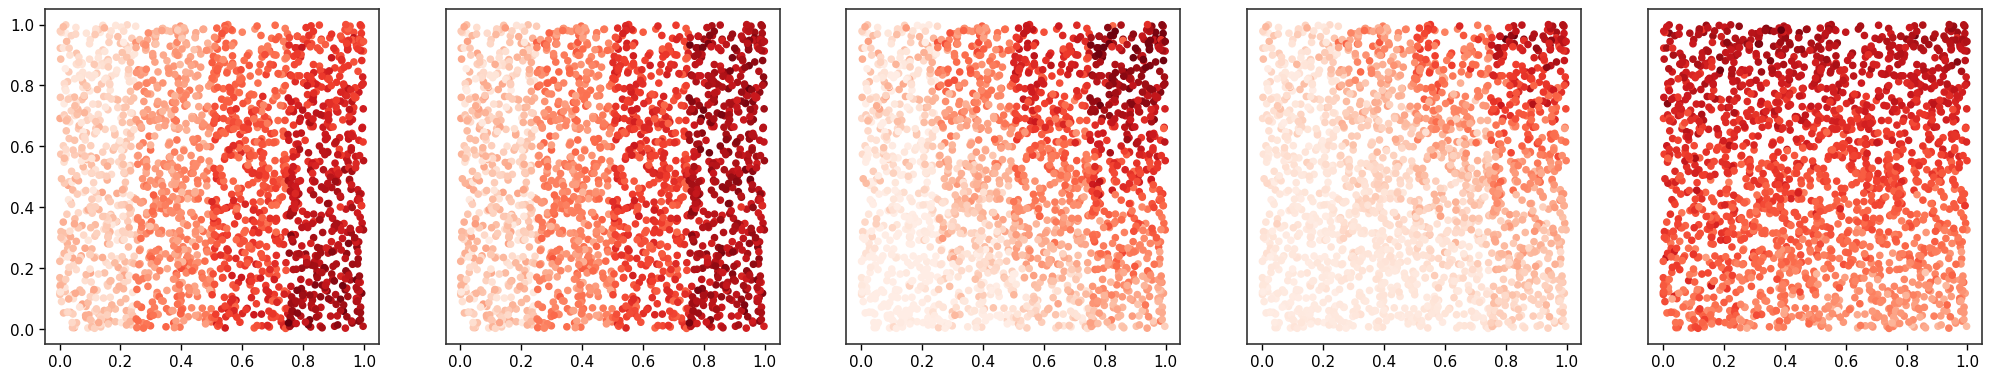

In [56]:
# plot 3 factors
import seaborn as sns
from spatialdata_plot.pl.utils import set_zero_in_cmap_to_transparent
from matplotlib.colors import ListedColormap, TwoSlopeNorm
new_cmap_1 = set_zero_in_cmap_to_transparent(cmap=sns.color_palette("Reds", as_cmap=True))
colors=new_cmap_1(np.arange(new_cmap_1.N))
colors = colors[new_cmap_1.N*1//20:new_cmap_1.N*4//4]
new_cmap_1 = ListedColormap(colors)
new_cmap_1
factor_ct_df = pd.DataFrame(factor_ct_df, index=adata_result.obs_names, columns=show_order)
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for i, ax in enumerate(axes.flat):
    ax.scatter(
        adata_result.obsm["spatial"][:, 0],
        adata_result.obsm["spatial"][:, 1],
        c=factor_ct_df.iloc[:, i],
        s=20,
        cmap=new_cmap_1,
    )
    #ax.set_xticks([])
    if i != 0:
        ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')
plt.savefig(os.path.join(FIG_PATH, 'simulated_factors_scatter_shift.pdf'))
plt.show()

## c = 0.1

In [20]:
c=0.1
adata_result = sc.read_h5ad(os.path.join(SAVE_PATH, f'adata_result_macsgp_c{c}.h5ad'))
coords = adata_result.obsm['spatial']
factor_true = adata_result.obsm['simulated_factor']['celltype_0']
loading_true = adata_result.varm['simulated_loading'][:, 0]

In [21]:
for method in ['mofa', 'spicemix', 'stamp']:
    factor_i = pd.read_csv(os.path.join(SAVE_PATH, method, f'factors_{c}.csv'), index_col=0)
    adata_st = adata_result.copy()
    for i in range(factor_i.shape[1]):
        adata_st.obs[f'{method}_factor_{i}'] = factor_i.iloc[:, i].values
    # sc.pl.spatial(adata_st, color=[f'{method}_factor_{i}' for i in range(factor_i.shape[1])], 
    #               cmap='viridis', spot_size=0.05, ncols=5)
    # # draw in one row 

In [22]:
methods = ['mofa', 'spicemix', 'stamp']
factors_temp = []
loadings_temp = []
for method in methods:
    factor_i = pd.read_csv(os.path.join(SAVE_PATH, method, f'factors_{c}.csv'), index_col=0)
    factors_temp.append(factor_i)
    loading_i = pd.read_csv(os.path.join(SAVE_PATH, method, f'loadings_{c}.csv'), index_col=0)
    loading_i = loading_i.loc[adata_result.var_names, :]
    loadings_temp.append(loading_i)

factor_ct_df = (np.concatenate([factors_temp[0].iloc[:, 0].values.reshape(-1, 1), factors_temp[1].iloc[:, 4].values.reshape(-1, 1), 
                factors_temp[2].iloc[:, 2].values.reshape(-1, 1)], axis=1))

loading_ct_df = (np.concatenate([loadings_temp[0].iloc[:, 0].values.reshape(1, -1), loadings_temp[1].iloc[:, 4].values.reshape(1, -1), 
                loadings_temp[2].iloc[:, 2].values.reshape(1, -1)], axis=0))

factor_ct_df = pd.DataFrame(factor_ct_df, index=adata_st.obs_names, columns=methods)
loading_ct_df = pd.DataFrame(loading_ct_df, index=methods, columns=adata_st.var_names)

factor_ct_df['macsgp'] = adata_st[factor_ct_df.index, :].obsm['factor']['celltype_0']
factor_ct_df['true'] = pd.DataFrame(adata_st[factor_ct_df.index, :].obsm['simulated_factor']['celltype_0'].values, columns=['true'], index=factor_ct_df.index)
loading_ct_df.loc['macsgp', :] = adata_st[factor_ct_df.index, :].varm['loading']['celltype_0']

nmf_idx = 0  # TODO: change after visualization
nmf_factor_i  = pd.read_csv(os.path.join(SAVE_PATH, 'NMF', f'factors_{c}.csv'),  index_col=0)
nmf_loading_i = pd.read_csv(os.path.join(SAVE_PATH, 'NMF', f'loadings_{c}.csv'), index_col=0)
factor_ct_df['nmf'] = nmf_factor_i.iloc[:, nmf_idx].values
loading_ct_df.loc['nmf', :] = nmf_loading_i.iloc[:, nmf_idx].values

# normalized factor_ct_df to -1 to 1
factor_ct_df_norm = factor_ct_df.copy()
for col in factor_ct_df_norm.columns:
    min_val = factor_ct_df_norm[col].min()
    max_val = factor_ct_df_norm[col].max()
    factor_ct_df_norm[col] = 2 * (factor_ct_df_norm[col] - min_val) / (max_val - min_val) - 1

In [23]:
w = KNN.from_array(coords, k=9)
w.transform = 'r'  # 行标准化
spatial_coherence_c = []
bi = esda.Moran_BV(factor_ct_df['true'], factor_ct_df['nmf'], w, permutations=999)
spatial_coherence_c.append(abs(bi.I))
for method in methods:
    bi = esda.Moran_BV(factor_ct_df['true'], factor_ct_df[method], w, permutations=999)
    spatial_coherence_c.append(abs(bi.I))
bi = esda.Moran_BV(factor_ct_df['true'], factor_ct_df['macsgp'], w, permutations=999)
spatial_coherence_c.append(abs(bi.I))


adata_result.varm['simulated_loading'] = pd.DataFrame(adata_st.varm['simulated_loading'], index=adata_st.var_names, columns=['1'])
loading_ct_df = loading_ct_df.loc[['nmf', 'mofa', 'spicemix', 'stamp', 'macsgp'], :]
cor = pd.concat([loading_ct_df, adata_result.varm['simulated_loading'].T.abs()]).T.corr()['1'].abs()

spatial_coherence.loc[c] = spatial_coherence_c
program_coherence.loc[c] = cor[0:5].values

## c = 0.01

In [24]:
c=0.01
adata_result = sc.read_h5ad(os.path.join(SAVE_PATH, f'adata_result_macsgp_c{c}.h5ad'))
coords = adata_result.obsm['spatial']
factor_true = adata_result.obsm['simulated_factor']['celltype_0']
loading_true = adata_result.varm['simulated_loading'][:, 0]

In [25]:
for method in ['mofa', 'spicemix', 'stamp']:
    factor_i = pd.read_csv(os.path.join(SAVE_PATH, method, f'factors_{c}.csv'), index_col=0)
    adata_st = adata_result.copy()
    for i in range(factor_i.shape[1]):
        adata_st.obs[f'{method}_factor_{i}'] = factor_i.iloc[:, i].values
    # sc.pl.spatial(adata_st, color=[f'{method}_factor_{i}' for i in range(factor_i.shape[1])], 
    #               cmap='viridis', spot_size=0.05, ncols=5)
    # # draw in one row 

In [26]:
methods = ['mofa', 'spicemix', 'stamp']
factors_temp = []
loadings_temp = []
for method in methods:
    factor_i = pd.read_csv(os.path.join(SAVE_PATH, method, f'factors_{c}.csv'), index_col=0)
    factors_temp.append(factor_i)
    loading_i = pd.read_csv(os.path.join(SAVE_PATH, method, f'loadings_{c}.csv'), index_col=0)
    loading_i = loading_i.loc[adata_result.var_names, :]
    loadings_temp.append(loading_i)

factor_ct_df = (np.concatenate([factors_temp[0].iloc[:, 0].values.reshape(-1, 1), factors_temp[1].iloc[:, 3].values.reshape(-1, 1), 
                factors_temp[2].iloc[:, 2].values.reshape(-1, 1)], axis=1))

loading_ct_df = (np.concatenate([loadings_temp[0].iloc[:, 0].values.reshape(1, -1), loadings_temp[1].iloc[:, 3].values.reshape(1, -1), 
                loadings_temp[2].iloc[:, 2].values.reshape(1, -1)], axis=0))

factor_ct_df = pd.DataFrame(factor_ct_df, index=adata_st.obs_names, columns=methods)
loading_ct_df = pd.DataFrame(loading_ct_df, index=methods, columns=adata_st.var_names)

factor_ct_df['macsgp'] = adata_st[factor_ct_df.index, :].obsm['factor']['celltype_0']
factor_ct_df['true'] = pd.DataFrame(adata_st[factor_ct_df.index, :].obsm['simulated_factor']['celltype_0'].values, columns=['true'], index=factor_ct_df.index)
loading_ct_df.loc['macsgp', :] = adata_st[factor_ct_df.index, :].varm['loading']['celltype_0']

nmf_idx = 1  # TODO: change after visualization
nmf_factor_i  = pd.read_csv(os.path.join(SAVE_PATH, 'NMF', f'factors_{c}.csv'),  index_col=0)
nmf_loading_i = pd.read_csv(os.path.join(SAVE_PATH, 'NMF', f'loadings_{c}.csv'), index_col=0)
factor_ct_df['nmf'] = nmf_factor_i.iloc[:, nmf_idx].values
loading_ct_df.loc['nmf', :] = nmf_loading_i.iloc[:, nmf_idx].values

# normalized factor_ct_df to -1 to 1
factor_ct_df_norm = factor_ct_df.copy()
for col in factor_ct_df_norm.columns:
    min_val = factor_ct_df_norm[col].min()
    max_val = factor_ct_df_norm[col].max()
    factor_ct_df_norm[col] = 2 * (factor_ct_df_norm[col] - min_val) / (max_val - min_val) - 1

In [27]:
w = KNN.from_array(coords, k=9)
w.transform = 'r'  # 行标准化
spatial_coherence_c = []
bi = esda.Moran_BV(factor_ct_df['true'], factor_ct_df['nmf'], w, permutations=999)
spatial_coherence_c.append(abs(bi.I))
for method in methods:
    bi = esda.Moran_BV(factor_ct_df['true'], factor_ct_df[method], w, permutations=999)
    spatial_coherence_c.append(abs(bi.I))
bi = esda.Moran_BV(factor_ct_df['true'], factor_ct_df['macsgp'], w, permutations=999)
spatial_coherence_c.append(abs(bi.I))


adata_result.varm['simulated_loading'] = pd.DataFrame(adata_st.varm['simulated_loading'], index=adata_st.var_names, columns=['1'])
loading_ct_df = loading_ct_df.loc[['nmf', 'mofa', 'spicemix', 'stamp', 'macsgp'], :]
cor = pd.concat([loading_ct_df, adata_result.varm['simulated_loading'].T.abs()]).T.corr()['1'].abs()

spatial_coherence.loc[c] = spatial_coherence_c
program_coherence.loc[c] = cor[0:5].values

In [28]:
spatial_coherence

,nmf,mofa,spicemix,stamp,macsgp
0.005,NaN,NaN,NaN,NaN,NaN
0.010,0.513795,0.056164,0.006023,0.612007,0.668027
0.100,0.165568,0.053504,0.685549,0.627164,0.87468
1.000,0.169722,0.057406,0.570883,0.626342,0.883166
100.000,0.181889,0.052297,0.627418,0.611209,0.880838


In [29]:
program_coherence

,nmf,mofa,spicemix,stamp,macsgp
0.005,NaN,NaN,NaN,NaN,NaN
0.010,0.199122,0.054447,0.173844,0.352384,0.698059
0.100,0.233222,0.056882,0.045567,0.349087,0.806255
1.000,0.245696,0.058292,0.068788,0.35724,0.813443
100.000,0.232451,0.056999,0.14889,0.325548,0.803881


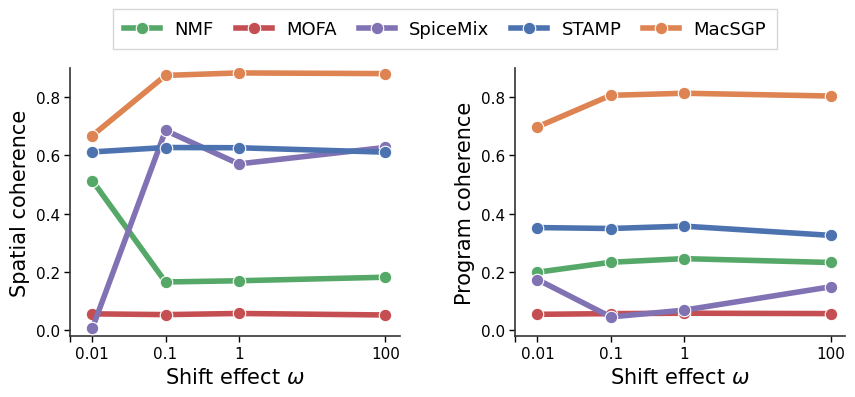

In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    #'font.family': 'Arial',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

# 自定义图例名：key 为 DataFrame 列名，value 为显示名
legend_names = {
    'mofa':       'MOFA',
    'spicemix':       'SpiceMix',
    'stamp':      'STAMP',
    'macsgp': 'MacSGP',
    'nmf':    'NMF',
}

colors = [ '#55A868', '#C44E52', '#8172B3', '#4C72B0', '#DD8452']
          #'#F39B7F', '#8491B4', '#91D1C2', '#DC9E82']
markers = ['o', 'o', 'o', 'o', 'o']
methods = spatial_coherence.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.subplots_adjust(top=0.78, wspace=0.35)

lines = []
labels = []

for ax, df, title, ylabel in [
    (axes[0], spatial_coherence, '', "Spatial coherence"),
    (axes[1], program_coherence, '', 'Program coherence'),
]:
    for i, method in enumerate(methods):
        line, = ax.plot(
            df.index, df[method],
            color=colors[i % len(colors)],
            marker=markers[i % len(markers)],
            markersize=9,
            markeredgecolor='white',
            markeredgewidth=0.8,
            linewidth=4,
            zorder=3,
        )
        if ax is axes[0]:
            lines.append(line)
            labels.append(legend_names.get(method, method))

    ax.set_xscale('log')
    ax.set_title(title, pad=10)
    ax.set_xlabel(f'Shift effect $\omega$', fontsize=15)
    ax.set_ylim(-0.02, 0.9)
    ax.set_ylabel(ylabel, fontsize=15)
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8])
    ax.set_xticks(c_list)
    ax.set_xticklabels([str(c) if c != c_list[0] else '' for c in c_list])
    ax.get_xaxis().set_major_formatter(ticker.FixedFormatter(
        ['' if c == c_list[0] else str(c) for c in c_list]
    ))
    ax.get_xaxis().set_tick_params(which='minor', size=0, width=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    #ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.8)

fig.legend(
    lines, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.95),
    ncol=len(labels),
    frameon=True,
    fancybox=False,
    edgecolor='#cccccc',
    borderpad=0.6,
    columnspacing=1.2,
    fontsize=13,
)

# plt.savefig(os.path.join(FIG_PATH, 'coherence_comparison.pdf'), dpi=300, bbox_inches='tight')
plt.show()

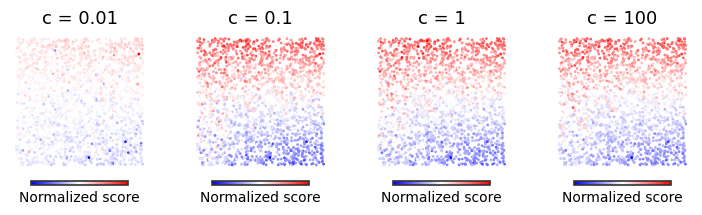

In [31]:
import os
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.colors import TwoSlopeNorm
RESULT_PATH = "/import/home2/share/yqzeng/MacSGP/results/simulation/shifted"
c_list = [0.01, 0.1, 1, 100]

fig, axes = plt.subplots(1, 4, figsize=(2.2 * 4, 2.4),
                         gridspec_kw={'wspace': 0.3})

for ax, c in zip(axes, c_list):
    adata = sc.read_h5ad(os.path.join(RESULT_PATH, f'adata_result_macsgp_c{c}.h5ad'))
    coords = adata.obsm['spatial']
    x, y = coords[:, 0], coords[:, 1]

    data = adata.obsm['factor']['celltype_0'].values.ravel()
    true = adata.obsm['simulated_factor']['celltype_0'].values.ravel()
    if np.corrcoef(data, true)[0, 1] < 0:
        data = -data
    #data = 2 * (data - data.min()) / (data.max() - data.min()) - 1
    vmin, vmax = data.min(), data.max()
    norm = TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)
    sc_plot = ax.scatter(x, y, c=data, s=4, cmap='bwr', linewidths=0, 
                         norm=norm
                         )

    cb = fig.colorbar(sc_plot, ax=ax, shrink=0.7, pad=0.05, orientation='horizontal')
    cb.set_label('Normalized score', fontsize=10)
    #cb.set_ticks([vmin, 0, vmax])
    cb.set_ticks([])
    #cb.ax.set_xticklabels([f'{vmin:.1f}', '0', f'{vmax:.1f}'])
    cb.ax.tick_params(labelsize=8)
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(0)
    ax.spines['bottom'].set_linewidth(0)

    ax.set_title(f'c = {c}', fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout(pad=0.3)
# plt.savefig(os.path.join(FIG_PATH, 'macsgp_factor_shifted.pdf'), dpi=300, bbox_inches='tight')
plt.show()


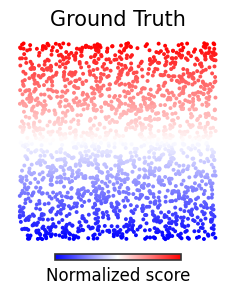

In [32]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator

data = adata.obsm['simulated_factor']['celltype_0'].values.ravel()

fig, ax = plt.subplots(figsize=(3.5, 3.2))
norm = mpl.colors.TwoSlopeNorm(vcenter=0.0)
sc = ax.scatter(
    x,
    y,
    c=data,
    s=8,
    cmap='bwr',
    linewidths=0,
    #norm=norm
)
cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
#cb.locator = MaxNLocator(nbins=1)
#cb.update_ticks()
#cb.ax.tick_params(labelsize=0)
cb.set_label('Normalized score', fontsize=12)
# no ticks
cb.set_ticks([])

# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title('Ground Truth', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()

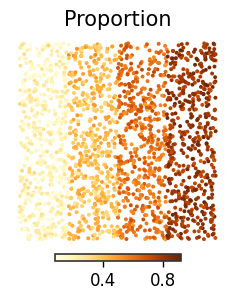

In [33]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator

data = adata.obsm['proportion']['celltype_0'].values.ravel()

fig, ax = plt.subplots(figsize=(3.5, 3.2))
norm = mpl.colors.TwoSlopeNorm(vcenter=0.0)
sc = ax.scatter(
    x,
    y,
    c=data,
    s=8,
    cmap='YlOrBr',
    linewidths=0,
    #norm=norm
)
cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
cb.locator = MaxNLocator(nbins=1)
cb.update_ticks()
cb.ax.tick_params(labelsize=12)

# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title('Proportion', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()

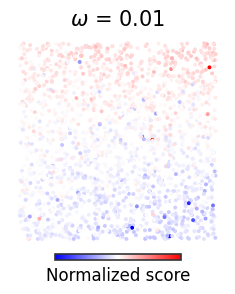

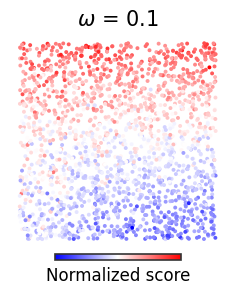

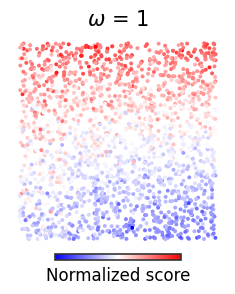

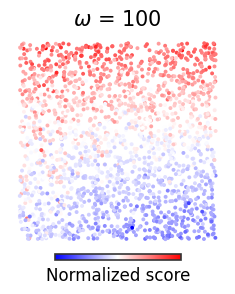

In [34]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scanpy as sc
from matplotlib.ticker import MaxNLocator
for c in [0.01, 0.1, 1, 100]:
    adata = sc.read_h5ad(os.path.join(RESULT_PATH, f'adata_result_macsgp_c{c}.h5ad'))
    coords = adata.obsm['spatial']
    x, y = coords[:, 0], coords[:, 1]

    data = adata.obsm['factor']['celltype_0'].values.ravel()
    true = adata.obsm['simulated_factor']['celltype_0'].values.ravel()
    if np.corrcoef(data, true)[0, 1] < 0:
        data = -data
    fig, ax = plt.subplots(figsize=(3.5, 3.2))
    norm = mpl.colors.TwoSlopeNorm(vcenter=0.0)
    sc1 = ax.scatter(
        x,
        y,
        c=data,
        s=8,
        cmap='bwr',
        linewidths=0,
        norm=norm
    )
    cb   = fig.colorbar(sc1, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
    #cb.locator = MaxNLocator(nbins=1)
    #cb.update_ticks()
    #cb.ax.tick_params(labelsize=0)
    cb.set_label('Normalized score', fontsize=12)
    # no ticks
    cb.set_ticks([])

    # 去掉边框
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(False)
    ax.spines['bottom'].set_linewidth(False)

    ax.set_title(f'$\omega$ = {c}', fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()

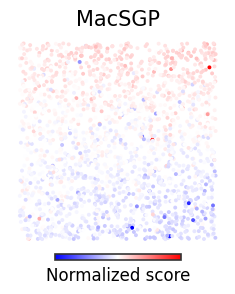

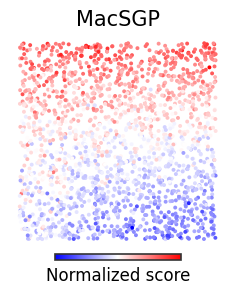

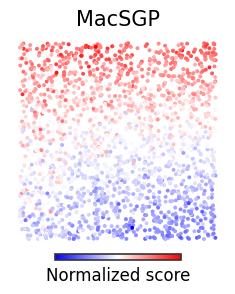

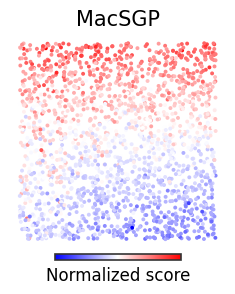

In [35]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scanpy as sc
from matplotlib.ticker import MaxNLocator
for c in [0.01, 0.1, 1, 100]:
    adata = sc.read_h5ad(os.path.join(RESULT_PATH, f'adata_result_macsgp_c{c}.h5ad'))
    coords = adata.obsm['spatial']
    x, y = coords[:, 0], coords[:, 1]

    data = adata.obsm['factor']['celltype_0'].values.ravel()
    true = adata.obsm['simulated_factor']['celltype_0'].values.ravel()
    if np.corrcoef(data, true)[0, 1] < 0:
        data = -data
    fig, ax = plt.subplots(figsize=(3.5, 3.2))
    norm = mpl.colors.TwoSlopeNorm(vcenter=0.0)
    sc1 = ax.scatter(
        x,
        y,
        c=data,
        s=8,
        cmap='bwr',
        linewidths=0,
        norm=norm
    )
    cb   = fig.colorbar(sc1, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
    #cb.locator = MaxNLocator(nbins=1)
    #cb.update_ticks()
    #cb.ax.tick_params(labelsize=0)
    cb.set_label('Normalized score', fontsize=12)
    # no ticks
    cb.set_ticks([])

    # 去掉边框
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(False)
    ax.spines['bottom'].set_linewidth(False)

    #ax.set_title(f'$\omega$ = {c}', fontsize=15)
    ax.set_title('MacSGP', fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()

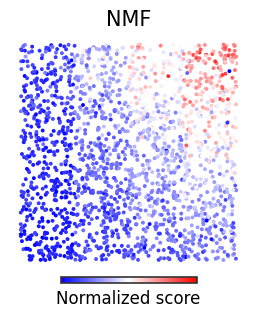

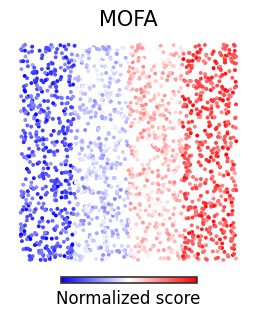

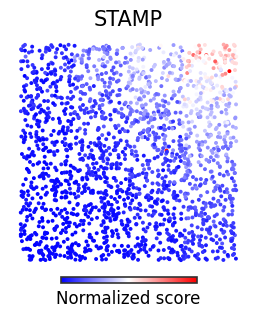

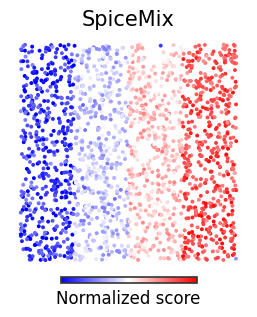

In [36]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

RESULT_PATH = "/import/home2/share/yqzeng/MacSGP/results/simulation/shifted"
c = 0.01

adata = sc.read_h5ad(os.path.join(RESULT_PATH, f'adata_result_macsgp_c{c}.h5ad'))
coords = adata.obsm['spatial']
x, y  = coords[:, 0], coords[:, 1]

# factor index selection for c=0.01
method_cfg = {
    # 'True':     adata.obsm['simulated_factor']['celltype_0'].values.ravel(),
    # 'MacSGP':   adata.obsm['factor']['celltype_0'].values.ravel(),
    'NMF':      pd.read_csv(os.path.join(RESULT_PATH, 'NMF',     f'factors_{c}.csv'), index_col=0).iloc[:, 1].values,
    'MOFA':     pd.read_csv(os.path.join(RESULT_PATH, 'mofa',    f'factors_{c}.csv'), index_col=0).iloc[:, 0].values,
    'STAMP':    pd.read_csv(os.path.join(RESULT_PATH, 'stamp',   f'factors_{c}.csv'), index_col=0).iloc[:, 2].values,
    'SpiceMix': pd.read_csv(os.path.join(RESULT_PATH, 'spicemix',f'factors_{c}.csv'), index_col=0).iloc[:, 3].values,
}

true_factor = adata.obsm['simulated_factor']['celltype_0'].values.ravel(),

# fig, axes = plt.subplots(1, len(method_cfg), figsize=(2.6 * len(method_cfg), 2.4),
#                          gridspec_kw={'wspace': 0.3})

for (title, data) in method_cfg.items():
    fig, ax = plt.subplots(figsize=(3.5, 3.2))
    # sign-align with true factor
    # if title != 'True' and np.corrcoef(data, true_factor)[0, 1] < 0:
    #     data = -data
    data = 2 * (data - data.min()) / (data.max() - data.min()) - 1
    #print(data.min(), data.max())
    vmin, vmax = -1, 1
    norm = TwoSlopeNorm(vmin=vmin, vmax=vmax, vcenter=0)
    sc_plot = ax.scatter(x, y, c=data, s=8, cmap='bwr', linewidths=0, 
                         norm=norm
                         )

    cb   = fig.colorbar(sc1, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
    #cb.locator = MaxNLocator(nbins=1)
    #cb.update_ticks()
    #cb.ax.tick_params(labelsize=0)
    cb.set_label('Normalized score', fontsize=12)
    # no ticks
    cb.set_ticks([])

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(0)
    ax.spines['bottom'].set_linewidth(0)
    ax.set_title(title, fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')

#plt.suptitle(f'c = {c}  (small shift)', fontsize=13, y=1.02)
    plt.tight_layout(pad=0.3)
    # plt.savefig(os.path.join(FIG_PATH, f'all_methods_c{c}.pdf'), dpi=300, bbox_inches='tight')
    plt.show()


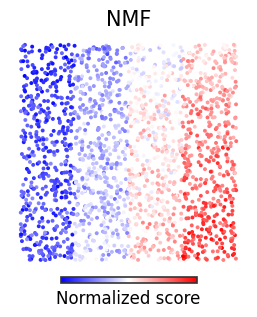

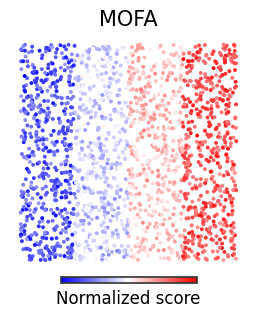

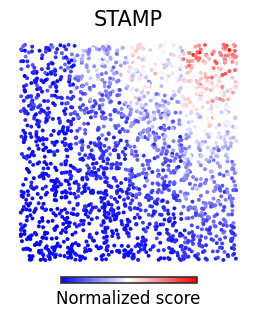

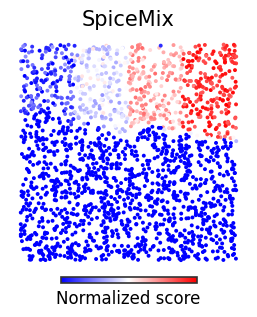

In [37]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

RESULT_PATH = "/import/home2/share/yqzeng/MacSGP/results/simulation/shifted"
c = 0.1

adata = sc.read_h5ad(os.path.join(RESULT_PATH, f'adata_result_macsgp_c{c}.h5ad'))
coords = adata.obsm['spatial']
x, y  = coords[:, 0], coords[:, 1]

# factor index selection for c=0.1
method_cfg = {
    # 'True':     adata.obsm['simulated_factor']['celltype_0'].values.ravel(),
    # 'MacSGP':   adata.obsm['factor']['celltype_0'].values.ravel(),
    'NMF':      pd.read_csv(os.path.join(RESULT_PATH, 'NMF',     f'factors_{c}.csv'), index_col=0).iloc[:, 0].values,
    'MOFA':     pd.read_csv(os.path.join(RESULT_PATH, 'mofa',    f'factors_{c}.csv'), index_col=0).iloc[:, 0].values,
    'STAMP':    pd.read_csv(os.path.join(RESULT_PATH, 'stamp',   f'factors_{c}.csv'), index_col=0).iloc[:, 2].values,
    'SpiceMix': pd.read_csv(os.path.join(RESULT_PATH, 'spicemix',f'factors_{c}.csv'), index_col=0).iloc[:, 4].values,
}

true_factor = adata.obsm['simulated_factor']['celltype_0'].values.ravel(),

# fig, axes = plt.subplots(1, len(method_cfg), figsize=(2.6 * len(method_cfg), 2.4),
#                          gridspec_kw={'wspace': 0.3})

for (title, data) in method_cfg.items():
    fig, ax = plt.subplots(figsize=(3.5, 3.2))
    # sign-align with true factor
    # if title != 'True' and np.corrcoef(data, true_factor)[0, 1] < 0:
    #     data = -data
    data = 2 * (data - data.min()) / (data.max() - data.min()) - 1
    #print(data.min(), data.max())
    vmin, vmax = -1, 1
    norm = TwoSlopeNorm(vmin=vmin, vmax=vmax, vcenter=0)
    sc_plot = ax.scatter(x, y, c=data, s=8, cmap='bwr', linewidths=0, 
                         norm=norm
                         )

    cb   = fig.colorbar(sc1, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
    #cb.locator = MaxNLocator(nbins=1)
    #cb.update_ticks()
    #cb.ax.tick_params(labelsize=0)
    cb.set_label('Normalized score', fontsize=12)
    # no ticks
    cb.set_ticks([])

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(0)
    ax.spines['bottom'].set_linewidth(0)
    ax.set_title(title, fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')

#plt.suptitle(f'c = {c}  (small shift)', fontsize=13, y=1.02)
    plt.tight_layout(pad=0.3)
    # plt.savefig(os.path.join(FIG_PATH, f'all_methods_c{c}.pdf'), dpi=300, bbox_inches='tight')
    plt.show()

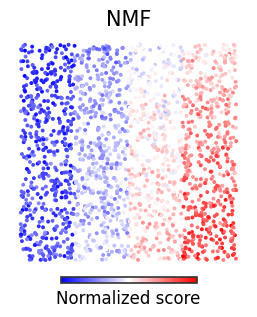

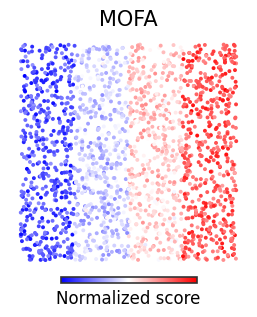

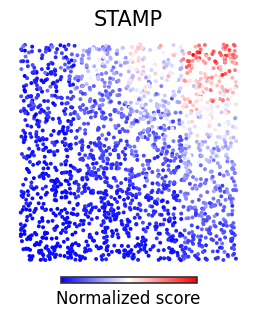

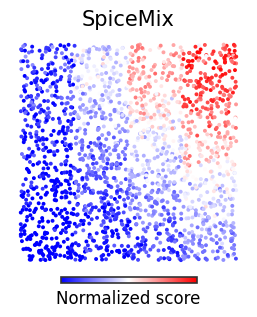

In [38]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

RESULT_PATH = "/import/home2/share/yqzeng/MacSGP/results/simulation/shifted"
c = 1

adata = sc.read_h5ad(os.path.join(RESULT_PATH, f'adata_result_macsgp_c{c}.h5ad'))
coords = adata.obsm['spatial']
x, y  = coords[:, 0], coords[:, 1]

# factor index selection for c=1
method_cfg = {
    # 'True':     adata.obsm['simulated_factor']['celltype_0'].values.ravel(),
    # 'MacSGP':   adata.obsm['factor']['celltype_0'].values.ravel(),
    'NMF':      pd.read_csv(os.path.join(RESULT_PATH, 'NMF',     f'factors_{c}.csv'), index_col=0).iloc[:, 0].values,
    'MOFA':     pd.read_csv(os.path.join(RESULT_PATH, 'mofa',    f'factors_{c}.csv'), index_col=0).iloc[:, 0].values,
    'STAMP':    pd.read_csv(os.path.join(RESULT_PATH, 'stamp',   f'factors_{c}.csv'), index_col=0).iloc[:, 2].values,
    'SpiceMix': pd.read_csv(os.path.join(RESULT_PATH, 'spicemix',f'factors_{c}.csv'), index_col=0).iloc[:, 3].values,
}

true_factor = adata.obsm['simulated_factor']['celltype_0'].values.ravel(),

# fig, axes = plt.subplots(1, len(method_cfg), figsize=(2.6 * len(method_cfg), 2.4),
#                          gridspec_kw={'wspace': 0.3})

for (title, data) in method_cfg.items():
    fig, ax = plt.subplots(figsize=(3.5, 3.2))
    # sign-align with true factor
    # if title != 'True' and np.corrcoef(data, true_factor)[0, 1] < 0:
    #     data = -data
    data = 2 * (data - data.min()) / (data.max() - data.min()) - 1
    #print(data.min(), data.max())
    vmin, vmax = -1, 1
    norm = TwoSlopeNorm(vmin=vmin, vmax=vmax, vcenter=0)
    sc_plot = ax.scatter(x, y, c=data, s=8, cmap='bwr', linewidths=0, 
                         norm=norm
                         )

    cb   = fig.colorbar(sc1, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
    #cb.locator = MaxNLocator(nbins=1)
    #cb.update_ticks()
    #cb.ax.tick_params(labelsize=0)
    cb.set_label('Normalized score', fontsize=12)
    # no ticks
    cb.set_ticks([])

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(0)
    ax.spines['bottom'].set_linewidth(0)
    ax.set_title(title, fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')

#plt.suptitle(f'c = {c}  (small shift)', fontsize=13, y=1.02)
    plt.tight_layout(pad=0.3)
    # plt.savefig(os.path.join(FIG_PATH, f'all_methods_c{c}.pdf'), dpi=300, bbox_inches='tight')
    plt.show()


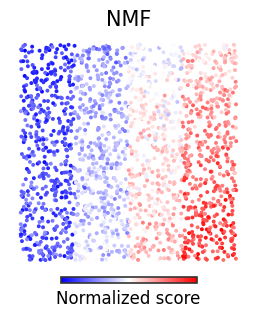

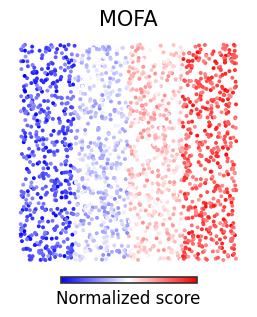

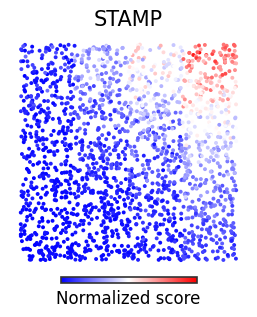

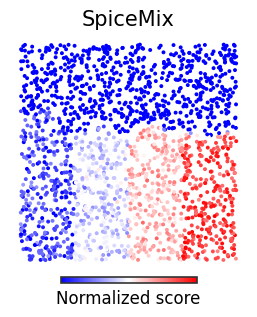

In [39]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

RESULT_PATH = "/import/home2/share/yqzeng/MacSGP/results/simulation/shifted"
c = 100

adata = sc.read_h5ad(os.path.join(RESULT_PATH, f'adata_result_macsgp_c{c}.h5ad'))
coords = adata.obsm['spatial']
x, y  = coords[:, 0], coords[:, 1]

# factor index selection for c=0.01
method_cfg = {
    # 'True':     adata.obsm['simulated_factor']['celltype_0'].values.ravel(),
    # 'MacSGP':   adata.obsm['factor']['celltype_0'].values.ravel(),
    'NMF':      pd.read_csv(os.path.join(RESULT_PATH, 'NMF',     f'factors_{c}.csv'), index_col=0).iloc[:, 0].values,
    'MOFA':     pd.read_csv(os.path.join(RESULT_PATH, 'mofa',    f'factors_{c}.csv'), index_col=0).iloc[:, 0].values,
    'STAMP':    pd.read_csv(os.path.join(RESULT_PATH, 'stamp',   f'factors_{c}.csv'), index_col=0).iloc[:, 2].values,
    'SpiceMix': pd.read_csv(os.path.join(RESULT_PATH, 'spicemix',f'factors_{c}.csv'), index_col=0).iloc[:, 3].values,
}

true_factor = adata.obsm['simulated_factor']['celltype_0'].values.ravel(),

# fig, axes = plt.subplots(1, len(method_cfg), figsize=(2.6 * len(method_cfg), 2.4),
#                          gridspec_kw={'wspace': 0.3})

for (title, data) in method_cfg.items():
    fig, ax = plt.subplots(figsize=(3.5, 3.2))
    # sign-align with true factor
    # if title != 'True' and np.corrcoef(data, true_factor)[0, 1] < 0:
    #     data = -data
    data = 2 * (data - data.min()) / (data.max() - data.min()) - 1
    #print(data.min(), data.max())
    vmin, vmax = -1, 1
    norm = TwoSlopeNorm(vmin=vmin, vmax=vmax, vcenter=0)
    sc_plot = ax.scatter(x, y, c=data, s=8, cmap='bwr', linewidths=0, 
                         norm=norm
                         )

    cb   = fig.colorbar(sc1, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
    #cb.locator = MaxNLocator(nbins=1)
    #cb.update_ticks()
    #cb.ax.tick_params(labelsize=0)
    cb.set_label('Normalized score', fontsize=12)
    # no ticks
    cb.set_ticks([])

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(0)
    ax.spines['bottom'].set_linewidth(0)
    ax.set_title(title, fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')

#plt.suptitle(f'c = {c}  (small shift)', fontsize=13, y=1.02)
    plt.tight_layout(pad=0.3)
    # plt.savefig(os.path.join(FIG_PATH, f'all_methods_c{c}.pdf'), dpi=300, bbox_inches='tight')
    plt.show()
